Device: cpu
Train: 54000
Val: 6000
Test: 10000


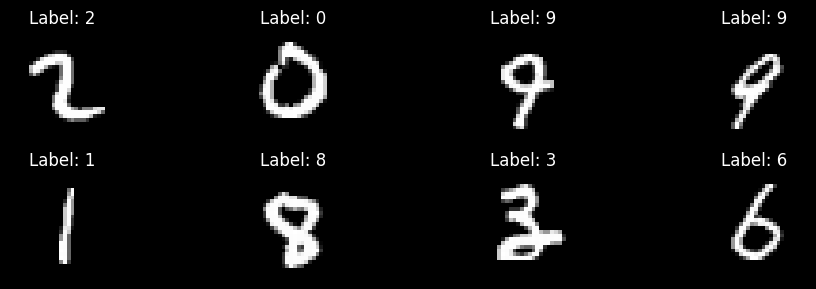

In [26]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Reproducibility + device

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#hyperparameters
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 13
WEIGHT_DECAY = 1e-4   # use for baseline
DROPOUT_P = 0.3
NUM_CLASSES = 10

#Load MNIST
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))


#sample
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [27]:
# DEFINE MODELS

class MLPReLURegularized(nn.Module):
    def __init__(self, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class MLPReLUNoReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class MLPSigmoid(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.Sigmoid(),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [28]:
# Train/Evaluate functions

def compute_accuracy(outputs, labels):
    preds = outputs.argmax(dim=1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_acc += compute_accuracy(outputs, labels) * batch_size
        total_samples += batch_size

    return total_loss / total_samples, total_acc / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_acc += compute_accuracy(outputs, labels) * batch_size
        total_samples += batch_size

    return total_loss / total_samples, total_acc / total_samples


def fit_model(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=0.0, device="cpu"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    return model, history

In [29]:
# Ploting function

def plot_history(history, title="Training History"):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

Epoch [1/13] | Train Loss: 0.4496 | Train Acc: 0.8675 | Val Loss: 0.1965 | Val Acc: 0.9422
Epoch [2/13] | Train Loss: 0.1859 | Train Acc: 0.9448 | Val Loss: 0.1364 | Val Acc: 0.9615
Epoch [3/13] | Train Loss: 0.1395 | Train Acc: 0.9585 | Val Loss: 0.1112 | Val Acc: 0.9673
Epoch [4/13] | Train Loss: 0.1154 | Train Acc: 0.9654 | Val Loss: 0.0986 | Val Acc: 0.9728
Epoch [5/13] | Train Loss: 0.0977 | Train Acc: 0.9703 | Val Loss: 0.0863 | Val Acc: 0.9740
Epoch [6/13] | Train Loss: 0.0879 | Train Acc: 0.9722 | Val Loss: 0.0878 | Val Acc: 0.9740
Epoch [7/13] | Train Loss: 0.0769 | Train Acc: 0.9767 | Val Loss: 0.0836 | Val Acc: 0.9750
Epoch [8/13] | Train Loss: 0.0708 | Train Acc: 0.9778 | Val Loss: 0.0806 | Val Acc: 0.9742
Epoch [9/13] | Train Loss: 0.0649 | Train Acc: 0.9800 | Val Loss: 0.0754 | Val Acc: 0.9773
Epoch [10/13] | Train Loss: 0.0637 | Train Acc: 0.9804 | Val Loss: 0.0744 | Val Acc: 0.9795
Epoch [11/13] | Train Loss: 0.0571 | Train Acc: 0.9818 | Val Loss: 0.0775 | Val Acc: 0.97

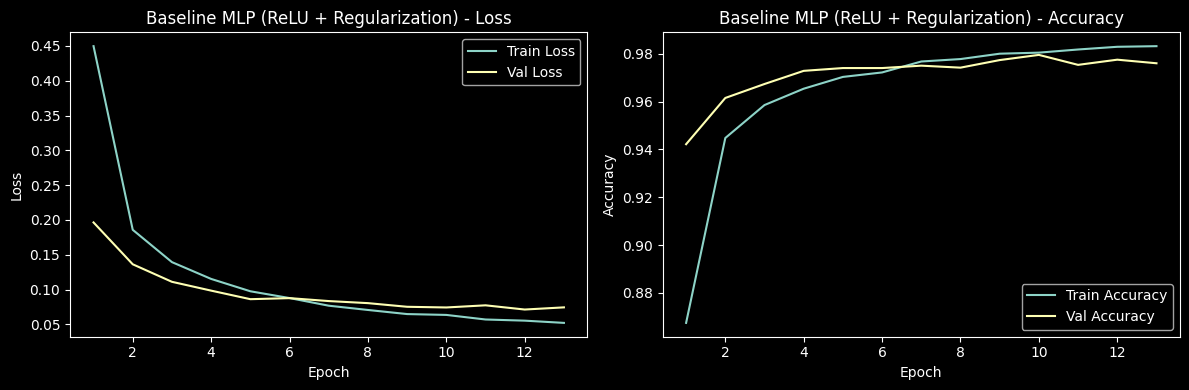

In [30]:
# Train baseline -> experiment 1: MLP + ReLU + regularization

baseline_model = MLPReLURegularized(dropout_p=DROPOUT_P)

baseline_model, baseline_history = fit_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=device
)

plot_history(baseline_history, title="Baseline MLP (ReLU + Regularization)")

Epoch [1/13] | Train Loss: 0.3710 | Train Acc: 0.8942 | Val Loss: 0.1896 | Val Acc: 0.9440
Epoch [2/13] | Train Loss: 0.1418 | Train Acc: 0.9584 | Val Loss: 0.1312 | Val Acc: 0.9603
Epoch [3/13] | Train Loss: 0.0936 | Train Acc: 0.9712 | Val Loss: 0.1079 | Val Acc: 0.9677
Epoch [4/13] | Train Loss: 0.0678 | Train Acc: 0.9794 | Val Loss: 0.0988 | Val Acc: 0.9720
Epoch [5/13] | Train Loss: 0.0514 | Train Acc: 0.9835 | Val Loss: 0.0975 | Val Acc: 0.9718
Epoch [6/13] | Train Loss: 0.0412 | Train Acc: 0.9869 | Val Loss: 0.1106 | Val Acc: 0.9682
Epoch [7/13] | Train Loss: 0.0318 | Train Acc: 0.9899 | Val Loss: 0.0873 | Val Acc: 0.9743
Epoch [8/13] | Train Loss: 0.0232 | Train Acc: 0.9931 | Val Loss: 0.0862 | Val Acc: 0.9770
Epoch [9/13] | Train Loss: 0.0190 | Train Acc: 0.9938 | Val Loss: 0.0947 | Val Acc: 0.9747
Epoch [10/13] | Train Loss: 0.0164 | Train Acc: 0.9946 | Val Loss: 0.0882 | Val Acc: 0.9760
Epoch [11/13] | Train Loss: 0.0161 | Train Acc: 0.9949 | Val Loss: 0.1127 | Val Acc: 0.97

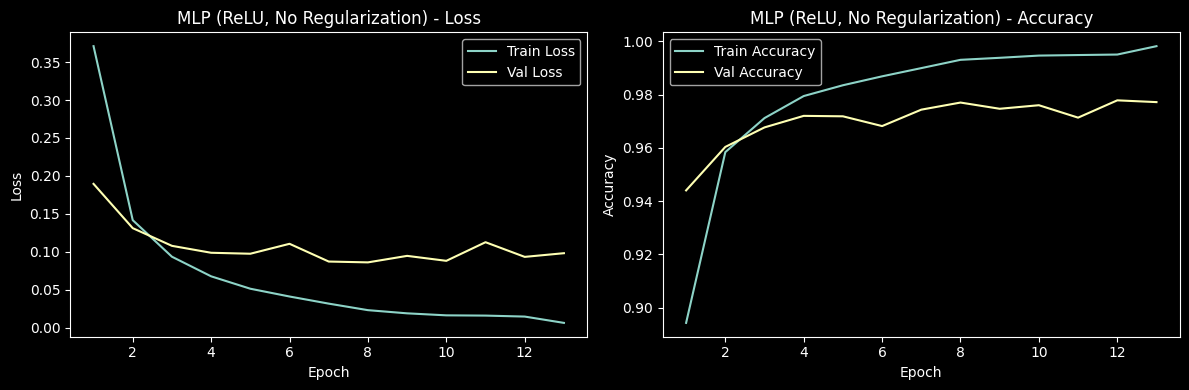

In [31]:
# EXP 2 — Remove regularization -> expect result : overfitting

no_reg_model = MLPReLUNoReg()

no_reg_model, no_reg_history = fit_model(
    no_reg_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=0.0,
    device=device
)

plot_history(no_reg_history, title="MLP (ReLU, No Regularization)")

### Short Conclusion : Regularization helps prevent overfitting by constraining model capacity and improving generalization, as evidenced by the smaller gap between training and validation metrics in the baseline model.

- Removing regularization leads to a significant increase in training accuracy, reaching nearly 99.8%, and training loss approaches zero.

- However, validation accuracy does not improve accordingly and remains around 98%. At the same time, validation loss increases and fluctuates during later epochs.

-> This indicates clear overfitting: the model memorizes the training data instead of learning generalizable patterns.

Compared to the baseline model, the gap between training and validation performance becomes significantly larger, confirming the importance of regularization techniques.

Epoch [1/13] | Train Loss: 0.7499 | Train Acc: 0.7993 | Val Loss: 0.3049 | Val Acc: 0.9098
Epoch [2/13] | Train Loss: 0.2394 | Train Acc: 0.9306 | Val Loss: 0.2206 | Val Acc: 0.9327
Epoch [3/13] | Train Loss: 0.1744 | Train Acc: 0.9488 | Val Loss: 0.1798 | Val Acc: 0.9445
Epoch [4/13] | Train Loss: 0.1365 | Train Acc: 0.9601 | Val Loss: 0.1498 | Val Acc: 0.9543
Epoch [5/13] | Train Loss: 0.1100 | Train Acc: 0.9676 | Val Loss: 0.1320 | Val Acc: 0.9588
Epoch [6/13] | Train Loss: 0.0904 | Train Acc: 0.9737 | Val Loss: 0.1163 | Val Acc: 0.9665
Epoch [7/13] | Train Loss: 0.0754 | Train Acc: 0.9778 | Val Loss: 0.1092 | Val Acc: 0.9675
Epoch [8/13] | Train Loss: 0.0627 | Train Acc: 0.9814 | Val Loss: 0.0994 | Val Acc: 0.9707
Epoch [9/13] | Train Loss: 0.0515 | Train Acc: 0.9848 | Val Loss: 0.0939 | Val Acc: 0.9703
Epoch [10/13] | Train Loss: 0.0437 | Train Acc: 0.9876 | Val Loss: 0.0880 | Val Acc: 0.9738
Epoch [11/13] | Train Loss: 0.0357 | Train Acc: 0.9902 | Val Loss: 0.0861 | Val Acc: 0.97

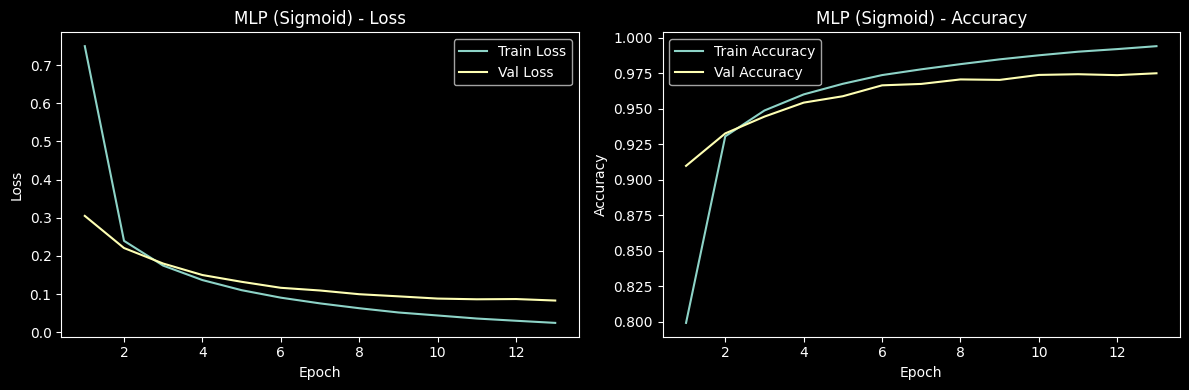

In [32]:
# EXP 3 : Sigmoid

sigmoid_model = MLPSigmoid()

sigmoid_model, sigmoid_history = fit_model(
    sigmoid_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=0.0,
    device=device
)

plot_history(sigmoid_history, title="MLP (Sigmoid)")

- Replacing ReLU with sigmoid results in slower convergence and lower final performance.

- During early epochs, the model with sigmoid activation learns significantly slower, as evidenced by lower training accuracy. This is due to the vanishing gradient problem, where gradients become very small when the input to the sigmoid function is in the saturated region.

As a result, weight updates become inefficient, especially in deeper layers, leading to slower learning and reduced overall accuracy.

In contrast, ReLU maintains a constant gradient for positive inputs, allowing faster and more stable training.

Epoch [1/13] | Train Loss: 0.3258 | Train Acc: 0.9020 | Val Loss: 0.1055 | Val Acc: 0.9700
Epoch [2/13] | Train Loss: 0.0833 | Train Acc: 0.9744 | Val Loss: 0.0680 | Val Acc: 0.9800
Epoch [3/13] | Train Loss: 0.0576 | Train Acc: 0.9819 | Val Loss: 0.0606 | Val Acc: 0.9817
Epoch [4/13] | Train Loss: 0.0467 | Train Acc: 0.9854 | Val Loss: 0.0482 | Val Acc: 0.9855
Epoch [5/13] | Train Loss: 0.0370 | Train Acc: 0.9883 | Val Loss: 0.0504 | Val Acc: 0.9850
Epoch [6/13] | Train Loss: 0.0306 | Train Acc: 0.9908 | Val Loss: 0.0447 | Val Acc: 0.9870
Epoch [7/13] | Train Loss: 0.0249 | Train Acc: 0.9922 | Val Loss: 0.0381 | Val Acc: 0.9888
Epoch [8/13] | Train Loss: 0.0223 | Train Acc: 0.9929 | Val Loss: 0.0410 | Val Acc: 0.9890
Epoch [9/13] | Train Loss: 0.0181 | Train Acc: 0.9941 | Val Loss: 0.0368 | Val Acc: 0.9882
Epoch [10/13] | Train Loss: 0.0140 | Train Acc: 0.9955 | Val Loss: 0.0371 | Val Acc: 0.9897
Epoch [11/13] | Train Loss: 0.0120 | Train Acc: 0.9965 | Val Loss: 0.0536 | Val Acc: 0.98

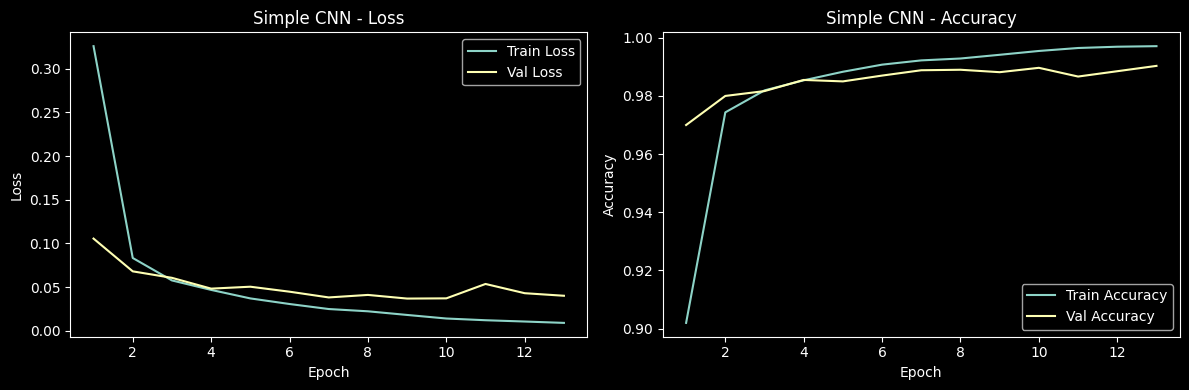

In [33]:
cnn_model = SimpleCNN()

cnn_model, cnn_history = fit_model(
    cnn_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=0.0,
    device=device
)

plot_history(cnn_history, title="Simple CNN")

- The CNN model significantly outperforms the MLP models in terms of validation accuracy, achieving approximately 99%.

- This improvement is due to the ability of convolutional layers to preserve spatial structure and learn local features such as edges and patterns.

Unlike MLP, which flattens the input and loses spatial information, CNN processes images in their original 2D form, allowing it to capture important visual features more effectively.

As a result, CNN demonstrates faster convergence, better generalization, and higher accuracy.